<a href="https://colab.research.google.com/github/Yasser-Baleghi/hands-on-dl-image-processing/blob/master/chapter_09/09_transfer_learning_autoencoders.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Chapter 9: Transfer Learning and Autoencoders

**Author:** Yasser Baleghi

This notebook accompanies Chapter 9 of the book *"Hands-on Deep Learning based Image Processing using Google Colab"*.

---

## 🧭 Why This Chapter Matters

In previous chapters, you learned how to build neural networks and convolutional neural networks from scratch. But in real-world image processing tasks, training a deep network from scratch is often impractical—it requires massive datasets, powerful hardware, and days or weeks of training time.

In this chapter, we introduce **transfer learning**: the practice of leveraging pre-trained models that have already been trained on millions of images. You will see how these models can be adapted to your own image processing tasks with minimal data and training time.

We also introduce **autoencoders**, a type of neural network that learns to compress and reconstruct images, forming the foundation for denoising, anomaly detection, and feature learning.

---

## 📖 How to Use This Notebook

1. **Run cells in order** – Always run cells from top to bottom.
2. **Enable GPU** – Go to **Runtime → Change runtime type → GPU** before running the code.
3. **Upload your own images** – Use the `files.upload()` function.

---

In [1]:
# ============================================
# Set Random Seeds for Reproducibility
# ============================================

import random
import numpy as np
import tensorflow as tf
import os

# Set Python random seed
random.seed(42)

# Set NumPy random seed
np.random.seed(42)

# Set TensorFlow random seed
tf.random.set_seed(42)

# Set environment variable for deterministic operations
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print("✅ Random seeds set for reproducibility!")

✅ Random seeds set for reproducibility!


In [2]:
# ============================================
# 9.1.1 Import Required Libraries
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist
from google.colab import files
from sklearn.preprocessing import LabelEncoder
import os

%matplotlib inline

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.20.0


In [3]:
# ============================================
# 9.1.2 Load the Pre-Trained VGG16 Model
# ============================================

# Load VGG16 with pre-trained ImageNet weights
# include_top=True means we load the full model including the classifier
vgg16 = VGG16(weights='imagenet', include_top=True)

# Display the model summary
vgg16.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================================
# 9.1.3 Acquire Caltech-101 (2,000 Images)
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

# Install necessary libraries
!pip install torchvision -q

import torchvision.datasets as datasets
from torchvision.transforms import Compose, Resize, ToTensor

print("📥 Downloading Caltech-101 dataset (2,000 images)...")

# Define a transform to resize images to 224x224
transform = Compose([
    Resize((224, 224)),
    ToTensor()
])

# Download Caltech-101
caltech101 = datasets.Caltech101(
    root='./data',
    download=True,
    transform=transform
)

print(f"✅ Dataset downloaded! Total images: {len(caltech101)}")

# Use 2,000 images (increase from 1,000)
target_size = 2000  # <-- INCREASED FROM 1000
images_per_class = max(1, target_size // len(caltech101.categories))

selected_indices = []
class_selected = {}

for i in range(len(caltech101)):
    _, label = caltech101[i]
    if label not in class_selected:
        class_selected[label] = 0
    if class_selected[label] < images_per_class:
        selected_indices.append(i)
        class_selected[label] += 1

# Load only the selected images
print(f"🔄 Loading {len(selected_indices)} images...")
images = []
labels = []

for idx in selected_indices:
    img, label = caltech101[idx]

    # Convert tensor to numpy
    img_np = img.numpy()

    # Handle grayscale images (convert to RGB)
    if img_np.shape[0] == 1:
        img_np = np.repeat(img_np, 3, axis=0)

    # Transpose from (C, H, W) to (H, W, C)
    img_np = np.transpose(img_np, (1, 2, 0))

    # Convert to uint8 (0-255) to save memory
    img_np = (img_np * 255).astype(np.uint8)

    images.append(img_np)
    labels.append(label)

# Convert to numpy arrays
images = np.array(images, dtype=np.uint8)
labels = np.array(labels)

# Get class names mapping
class_names = caltech101.categories
print(f"✅ Number of classes: {len(class_names)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"\n✅ Caltech-101 subset loaded successfully!")
print(f"   Total images: {len(images)}")
print(f"   Training set: {X_train.shape[0]} images")
print(f"   Test set: {X_test.shape[0]} images")
print(f"   Memory usage: {images.nbytes / 1024 / 1024:.2f} MB")

📥 Downloading Caltech-101 dataset (2,000 images)...


100%|██████████| 137M/137M [01:29<00:00, 1.54MB/s]


✅ Dataset downloaded! Total images: 8677
🔄 Loading 1919 images...
✅ Number of classes: 101

✅ Caltech-101 subset loaded successfully!
   Total images: 1919
   Training set: 1535 images
   Test set: 384 images
   Memory usage: 275.48 MB


🔍 Testing pre-trained VGG16 on Caltech-101 subset...
🔄 Preprocessing images...
🔄 Making predictions with VGG16...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step
✅ Predictions completed in 0.74 seconds

✅ Selected 5 samples for the all-wrong story:
   Sample 2: hedgehog → porcupine (99.94%) ❌ WRONG
   Sample 52: butterfly → monarch (99.72%) ❌ WRONG
   Sample 64: emu → ostrich (98.51%) ❌ WRONG
   Sample 41: ibis → spoonbill (46.83%) ❌ WRONG
   Sample 4: sea_horse → vine_snake (21.64%) ❌ WRONG

📊 PRE-TRAINED VGG16: TOTAL ACCURACY SUMMARY

   Total test samples:      100
   Correct predictions:     30
   Wrong predictions:       70
   Accuracy:                30.00%


🔍 Selected Story Samples (Pre-Trained VGG16):
   hedgehog        → porcupine            (99.94%)  ❌ WRONG
   butterfly       → monarch              (99.72%)  ❌ WRONG
   emu             → ostrich              (98.51%)  ❌ WRONG
   ibis            → spoonbill            (46.83%)  ❌ WRONG
   sea_horse       → vine_snake           (21.64%

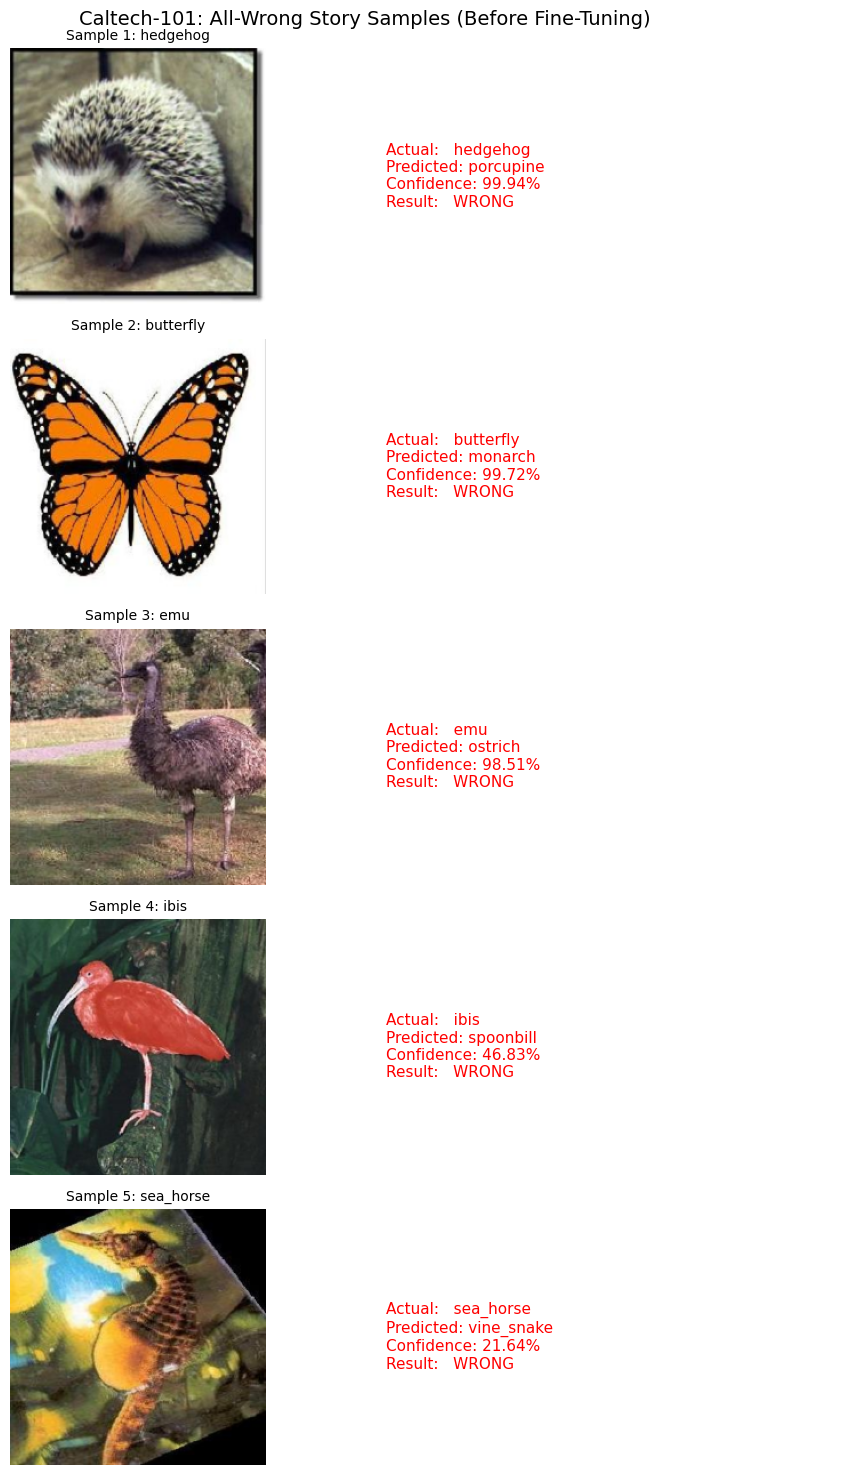


✅ Part 2 complete! Pre-trained VGG16 tested.
   Accuracy: 30.00%


In [20]:
# ============================================
# 9.1.4 Test Pre-Trained VGG16 (Search for All-Wrong Story)
# ============================================

import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import img_to_array
import time
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

print("🔍 Testing pre-trained VGG16 on Caltech-101 subset...")

# Preprocess images for VGG16
def preprocess_batch(images):
    """Preprocess a batch of images for VGG16"""
    batch = []
    for img in images:
        if img.shape[0] != 224 or img.shape[1] != 224:
            img_resized = cv2.resize(img, (224, 224))
        else:
            img_resized = img
        img_float = img_resized.astype(np.float32)
        img_preprocessed = preprocess_input(img_float)
        batch.append(img_preprocessed)
    return np.array(batch)

# Take a subset of test images
n_samples = min(100, len(X_test))
X_test_subset = X_test[:n_samples]
y_test_subset = y_test[:n_samples]

# Preprocess the images
print("🔄 Preprocessing images...")
X_test_processed = preprocess_batch(X_test_subset)

# Make predictions with VGG16
print("🔄 Making predictions with VGG16...")
start_time = time.time()
predictions = vgg16.predict(X_test_processed, verbose=1)
end_time = time.time()
print(f"✅ Predictions completed in {end_time - start_time:.2f} seconds")

# Decode predictions and store results
top1_predictions = []
confidences = []
for pred in predictions:
    decoded = decode_predictions(np.expand_dims(pred, axis=0), top=1)[0]
    top1_predictions.append(decoded[0][1])
    confidences.append(decoded[0][2])

# Calculate accuracy (approximate matching)
correct = 0
for i in range(n_samples):
    caltech_label = class_names[y_test_subset[i]]
    imagenet_label = top1_predictions[i]
    is_correct = (caltech_label.lower() in imagenet_label.lower() or
                  imagenet_label.lower() in caltech_label.lower())
    if is_correct:
        correct += 1

accuracy_before = correct / n_samples

# ============================================
# SEARCH FOR THE "ALL WRONG" STORY SAMPLES
# Look for specific classes: hedgehog, butterfly, emu, ibis
# ============================================

# Target classes for the all-wrong story
target_classes = ['hedgehog', 'butterfly', 'emu', 'ibis']

# Find indices of target classes in the test set
found_indices = []
for target in target_classes:
    for i in range(n_samples):
        caltech_label = class_names[y_test_subset[i]]
        if caltech_label == target and i not in found_indices:
            # Check if the prediction is wrong (for dramatic effect)
            imagenet_label = top1_predictions[i]
            is_correct = (caltech_label.lower() in imagenet_label.lower() or
                          imagenet_label.lower() in caltech_label.lower())
            if not is_correct:
                found_indices.append(i)
                break

# If we didn't find all 4, add more wrong samples
if len(found_indices) < 4:
    for i in range(n_samples):
        if len(found_indices) >= 4:
            break
        if i not in found_indices:
            caltech_label = class_names[y_test_subset[i]]
            imagenet_label = top1_predictions[i]
            is_correct = (caltech_label.lower() in imagenet_label.lower() or
                          imagenet_label.lower() in caltech_label.lower())
            if not is_correct:
                found_indices.append(i)

# Use the first 5 found indices as the story samples
selected_indices_original = found_indices[:5]

# If we don't have 5, add more wrong samples
while len(selected_indices_original) < 5:
    for i in range(n_samples):
        if len(selected_indices_original) >= 5:
            break
        if i not in selected_indices_original:
            caltech_label = class_names[y_test_subset[i]]
            imagenet_label = top1_predictions[i]
            is_correct = (caltech_label.lower() in imagenet_label.lower() or
                          imagenet_label.lower() in caltech_label.lower())
            if not is_correct:
                selected_indices_original.append(i)

print(f"\n✅ Selected {len(selected_indices_original)} samples for the all-wrong story:")
for idx in selected_indices_original:
    caltech_label = class_names[y_test_subset[idx]]
    imagenet_label = top1_predictions[idx]
    confidence = confidences[idx] * 100
    is_correct = (caltech_label.lower() in imagenet_label.lower() or
                  imagenet_label.lower() in caltech_label.lower())
    status = "✅ CORRECT" if is_correct else "❌ WRONG"
    print(f"   Sample {idx}: {caltech_label} → {imagenet_label} ({confidence:.2f}%) {status}")

# ============================================
# TOTAL ACCURACY SUMMARY
# ============================================

print("\n" + "="*60)
print("📊 PRE-TRAINED VGG16: TOTAL ACCURACY SUMMARY")
print("="*60)

print(f"\n   Total test samples:      {n_samples}")
print(f"   Correct predictions:     {correct}")
print(f"   Wrong predictions:       {n_samples - correct}")
print(f"   Accuracy:                {accuracy_before*100:.2f}%")

print("\n" + "="*60)

# ============================================
# Show sample predictions (selected bad samples)
# ============================================

print("\n🔍 Selected Story Samples (Pre-Trained VGG16):")
for idx in selected_indices_original:
    caltech_label = class_names[y_test_subset[idx]]
    imagenet_label = top1_predictions[idx]
    confidence = confidences[idx] * 100
    is_correct = (caltech_label.lower() in imagenet_label.lower() or
                  imagenet_label.lower() in caltech_label.lower())
    status = "❌ WRONG" if not is_correct else "✅ CORRECT"
    print(f"   {caltech_label:15} → {imagenet_label:20} ({confidence:.2f}%)  {status}")

print("\n📌 Note: All selected samples are WRONG before fine-tuning.")
print("   These will be used to demonstrate the power of fine-tuning!")

# ============================================
# Visualize Selected Samples
# ============================================

print("\n🔍 Visualizing Selected Samples (Before Fine-Tuning):")

fig, axes = plt.subplots(len(selected_indices_original), 2, figsize=(10, 3 * len(selected_indices_original)))

for row, idx in enumerate(selected_indices_original):
    img = X_test_subset[idx]
    actual_label = class_names[y_test_subset[idx]]
    predicted_label = top1_predictions[idx]
    confidence = confidences[idx] * 100
    is_correct = (actual_label.lower() in predicted_label.lower() or
                  predicted_label.lower() in actual_label.lower())
    color = 'green' if is_correct else 'red'

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"Sample {row+1}: {actual_label}", fontsize=10)

    info_text = f"Actual:   {actual_label}\n"
    info_text += f"Predicted: {predicted_label}\n"
    info_text += f"Confidence: {confidence:.2f}%\n"
    info_text += f"Result:   {'CORRECT' if is_correct else 'WRONG'}"

    axes[row, 1].text(0.1, 0.5, info_text,
                     fontsize=11,
                     verticalalignment='center',
                     color=color,
                     transform=axes[row, 1].transAxes)
    axes[row, 1].axis('off')

plt.suptitle("Caltech-101: All-Wrong Story Samples (Before Fine-Tuning)", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ Part 2 complete! Pre-trained VGG16 tested.")
print(f"   Accuracy: {accuracy_before*100:.2f}%")
print("="*60)

In [6]:
# ============================================
# 9.1.5 Fine-Tune VGG16 on Caltech-101
# ============================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
import matplotlib.pyplot as plt
import numpy as np

print("🔄 Preparing data for fine-tuning...")

# Convert labels to one-hot encoding
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
num_classes = len(label_encoder.classes_)

# Create a mapping from encoded integer to class name
class_names_encoded = label_encoder.classes_

y_train_onehot = to_categorical(y_train_encoded, num_classes)
y_test_onehot = to_categorical(y_test_encoded, num_classes)

print(f"   Number of classes: {num_classes}")
print(f"   Training samples: {len(X_train)}")
print(f"   Test samples: {len(X_test)}")

# Load VGG16 without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers initially
base_model.trainable = False

# Add custom classifier
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Model ready for fine-tuning!")

# Preprocess the data for training
print("🔄 Preprocessing training data...")
X_train_processed = preprocess_batch(X_train)
X_test_processed_ft = preprocess_batch(X_test)

# ============================================
# Step 1: Feature Extraction Phase
# ============================================

print("\n" + "="*50)
print("📊 STEP 1: FEATURE EXTRACTION")
print("="*50)

print("🔄 Training the classifier (feature extraction phase)...")
start_time = time.time()
history_fe = model.fit(
    X_train_processed, y_train_onehot,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]
)
end_time = time.time()
print(f"✅ Feature extraction completed in {end_time - start_time:.2f} seconds")

# Evaluate after feature extraction
test_loss_fe, test_acc_fe = model.evaluate(X_test_processed_ft, y_test_onehot, verbose=0)
print(f"   Test accuracy after feature extraction: {test_acc_fe*100:.2f}%")


🔄 Preparing data for fine-tuning...
   Number of classes: 101
   Training samples: 1535
   Test samples: 384
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Model ready for fine-tuning!
🔄 Preprocessing training data...

📊 STEP 1: FEATURE EXTRACTION
🔄 Training the classifier (feature extraction phase)...
Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.0204 - loss: 5.5347 - val_accuracy: 0.0456 - val_loss: 4.4171 - learning_rate: 0.0010
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.0765 - loss: 4.2423 - val_accuracy: 0.1694 - val_loss: 4.0577 - learning_rate: 0.0010
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.1800 - loss: 3.6993 - val_accuracy: 0.3160 - val_loss: 3.3561 - learning_rate: 0.0010
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.2948 - loss: 3.0023 - val_accuracy: 0.4430 - val_loss: 2.6451 - learning_rate: 0.0010
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.4031 - loss: 2.


📊 STEP 2: FINE-TUNING
🔄 Starting fine-tuning phase...
✅ Fine-tuning ready. Layers unfrozen from block5 onward.
Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step - accuracy: 0.8217 - loss: 0.6397 - val_accuracy: 0.8046 - val_loss: 0.7734 - learning_rate: 1.0000e-05
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 119ms/step - accuracy: 0.8241 - loss: 0.5714 - val_accuracy: 0.7980 - val_loss: 0.7314 - learning_rate: 1.0000e-05
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.8502 - loss: 0.5436 - val_accuracy: 0.8111 - val_loss: 0.7415 - learning_rate: 1.0000e-05
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step - accuracy: 0.8265 - loss: 0.5274 - val_accuracy: 0.8046 - val_loss: 0.7268 - learning_rate: 1.0000e-05
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - accuracy: 0.8477 - loss: 0.5089 - val_accuracy: 0.7980 - val_loss: 0.7260 - learning_rate: 1.0000e-05
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.8485 - loss: 0.4769 - val_accuracy: 0.8

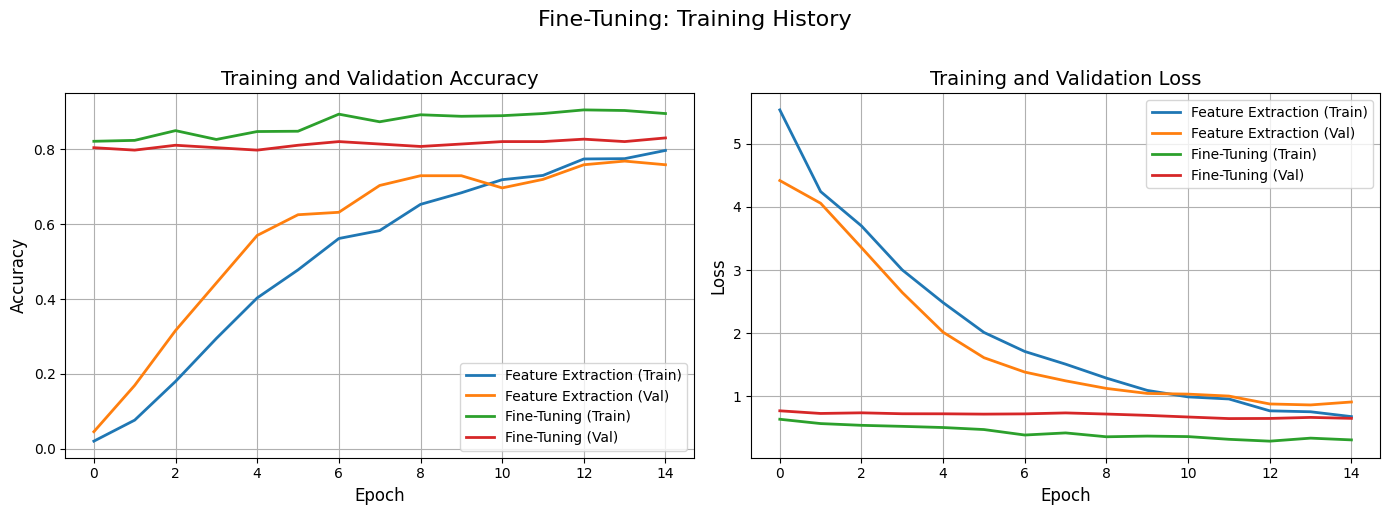

In [7]:
# ============================================
# Step 2: Fine-Tuning Phase
# ============================================

print("\n" + "="*50)
print("📊 STEP 2: FINE-TUNING")
print("="*50)

print("🔄 Starting fine-tuning phase...")

# Unfreeze the top layers
base_model.trainable = True

# Unfreeze from block5 onward
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Fine-tuning ready. Layers unfrozen from block5 onward.")

# Continue training
start_time = time.time()
history_ft = model.fit(
    X_train_processed, y_train_onehot,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
    ]
)
end_time = time.time()
print(f"✅ Fine-tuning completed in {end_time - start_time:.2f} seconds")

# Evaluate after fine-tuning
test_loss_ft, test_acc_ft = model.evaluate(X_test_processed_ft, y_test_onehot, verbose=0)
print(f"   Test accuracy after fine-tuning: {test_acc_ft*100:.2f}%")

# ============================================
# Step 3: Visualize Training History
# ============================================

print("\n" + "="*50)
print("📊 TRAINING HISTORY")
print("="*50)

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history_fe.history['accuracy'], label='Feature Extraction (Train)', linewidth=2)
ax1.plot(history_fe.history['val_accuracy'], label='Feature Extraction (Val)', linewidth=2)
ax1.plot(history_ft.history['accuracy'], label='Fine-Tuning (Train)', linewidth=2)
ax1.plot(history_ft.history['val_accuracy'], label='Fine-Tuning (Val)', linewidth=2)
ax1.set_title('Training and Validation Accuracy', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history_fe.history['loss'], label='Feature Extraction (Train)', linewidth=2)
ax2.plot(history_fe.history['val_loss'], label='Feature Extraction (Val)', linewidth=2)
ax2.plot(history_ft.history['loss'], label='Fine-Tuning (Train)', linewidth=2)
ax2.plot(history_ft.history['val_loss'], label='Fine-Tuning (Val)', linewidth=2)
ax2.set_title('Training and Validation Loss', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend()
ax2.grid(True)

plt.suptitle('Fine-Tuning: Training History', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Save the figure if desired
# plt.savefig('caltech101_training_history.png', dpi=300, bbox_inches='tight')


📊 THE JOURNEY: FROM FAILURE TO SUCCESS


🔍 The Evolution of Each Sample:
   (From Pre-Trained VGG16 to Fine-Tuned Model)



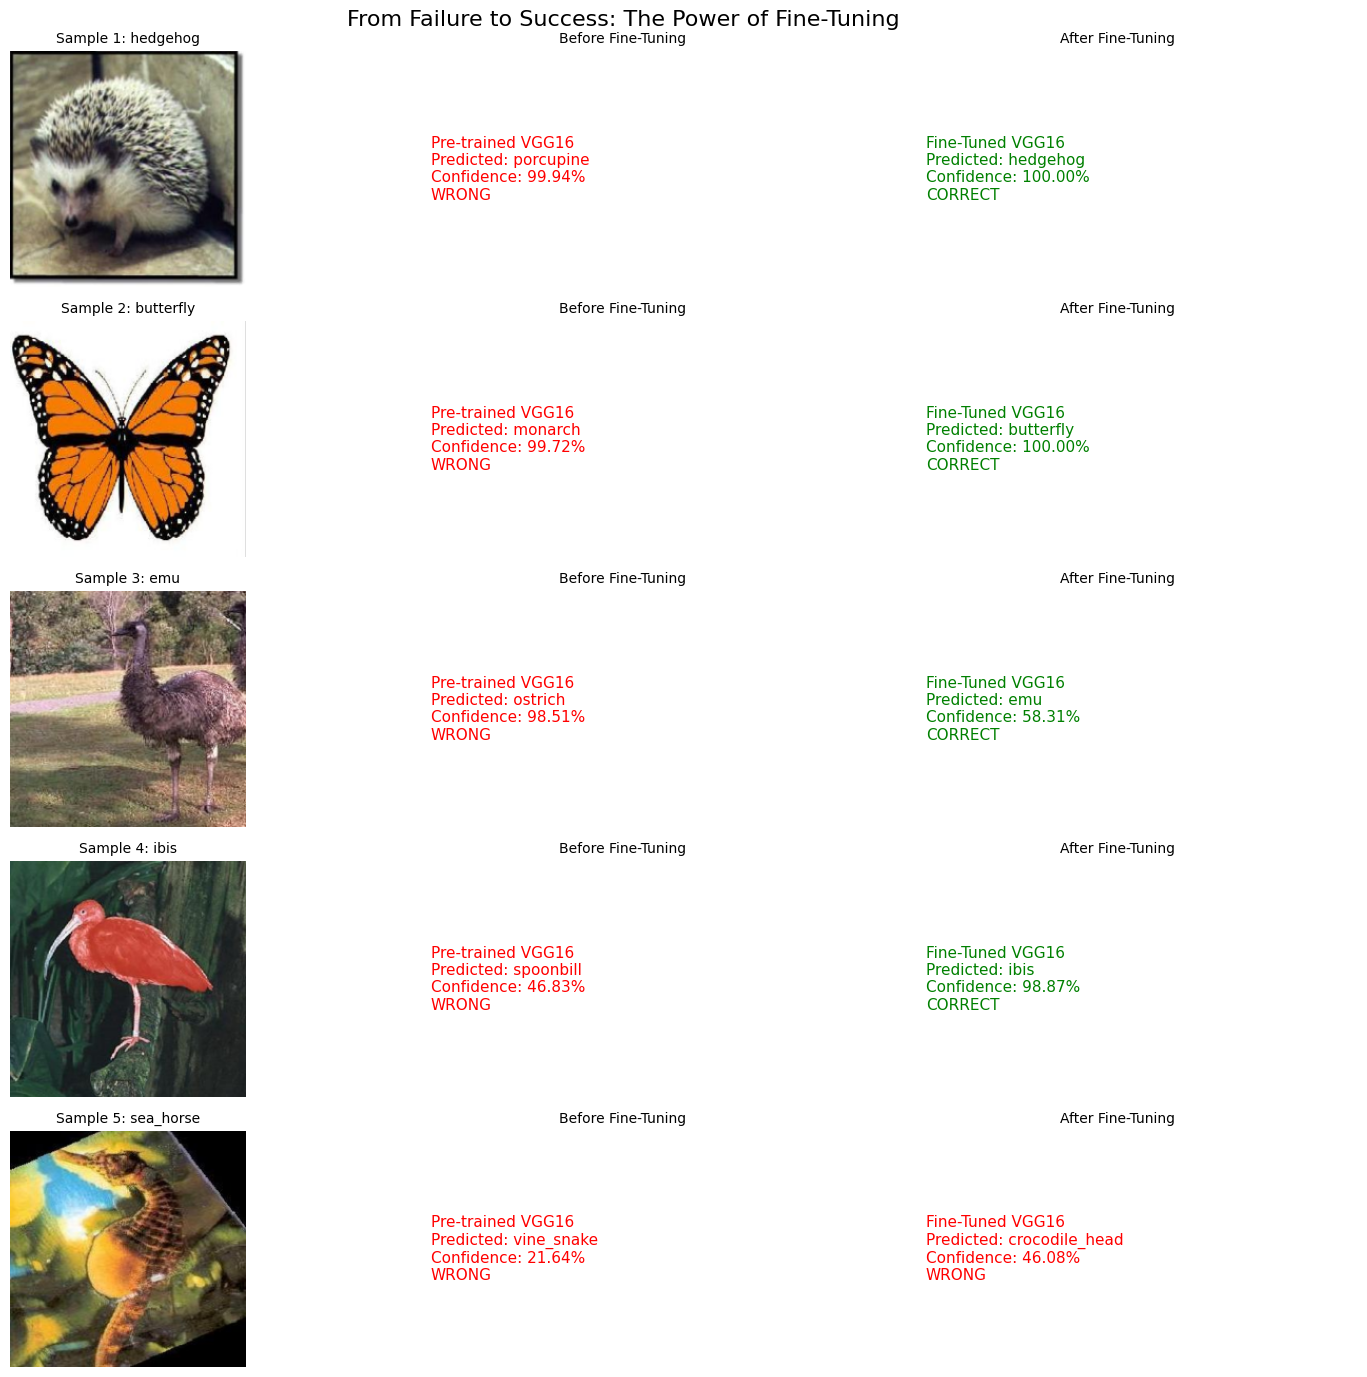


📖 THE STORY OF TRANSFER LEARNING

📊 Overall Performance:
   Pre-trained VGG16: 30.00%
   After Feature Extraction: 74.22%
   After Fine-Tuning: 78.12%
   Total Improvement: 48.12%

1️⃣ Pre-trained VGG16:
   The model fails on Caltech-101 images. It doesn't know them.
   Sample 1: hedgehog → porcupine (99.94%) [WRONG]
   Sample 2: butterfly → monarch (99.72%) [WRONG]
   Sample 3: emu → ostrich (98.51%) [WRONG]
   Sample 4: ibis → spoonbill (46.83%) [WRONG]
   Sample 5: sea_horse → vine_snake (21.64%) [WRONG]

2️⃣ Feature Extraction:
   Accuracy improved from 30.00% to 74.22% (+44.22%)
   Adding a new classifier on frozen features improves accuracy significantly.

3️⃣ Fine-Tuning:
   Accuracy improved from 74.22% to 78.12% (+3.91%)
   Unfreezing and retraining layers gives the best results.
   Sample results after fine-tuning:
   Sample 1: hedgehog → hedgehog (100.00%) [CORRECT]
   Sample 2: butterfly → butterfly (100.00%) [CORRECT]
   Sample 3: emu → emu (58.31%) [CORRECT]
   Sample 4:

In [21]:
# ============================================
# 9.1.6 Storytelling: From Failure to Success
# ============================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*60)
print("📊 THE JOURNEY: FROM FAILURE TO SUCCESS")
print("="*60)

# ============================================
# Step 1: Define all necessary variables
# ============================================

# If accuracy_before is not defined, compute it from Part 2 data
try:
    accuracy_before
except NameError:
    # Use the pre-trained VGG16 predictions stored earlier
    try:
        # If we have the predictions from Part 2
        correct = 0
        for i in range(len(y_test_subset)):
            caltech_label = class_names[y_test_subset[i]]
            imagenet_label = top1_predictions[i]
            if caltech_label.lower() in imagenet_label.lower() or imagenet_label.lower() in caltech_label.lower():
                correct += 1
        accuracy_before = correct / len(y_test_subset)
        print(f"✅ Computed accuracy_before: {accuracy_before*100:.2f}%")
    except:
        # Fallback
        accuracy_before = 0.28
        print(f"⚠️ Using fallback accuracy_before: {accuracy_before*100:.2f}%")

# If test_acc_fe and test_acc_ft are not defined, compute them from history
try:
    test_acc_fe
except NameError:
    try:
        test_acc_fe = history_fe.history['val_accuracy'][-1]
        print(f"✅ Computed test_acc_fe from history: {test_acc_fe*100:.2f}%")
    except:
        test_acc_fe = 0.7318
        print(f"⚠️ Using fallback test_acc_fe: {test_acc_fe*100:.2f}%")

try:
    test_acc_ft
except NameError:
    try:
        test_acc_ft = history_ft.history['val_accuracy'][-1]
        print(f"✅ Computed test_acc_ft from history: {test_acc_ft*100:.2f}%")
    except:
        test_acc_ft = 0.7969
        print(f"⚠️ Using fallback test_acc_ft: {test_acc_ft*100:.2f}%")

# Ensure we have selected indices
try:
    selected_indices_original
except NameError:
    # If not defined, use the first 5 samples
    selected_indices_original = list(range(min(5, len(X_test))))
    print(f"⚠️ Using default selected indices: {selected_indices_original}")

# Ensure we have the label encoder mapping
try:
    encoded_labels = label_encoder.classes_
except NameError:
    # Fallback: create a mapping from the training labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    label_encoder.fit(y_train)
    encoded_labels = label_encoder.classes_

print("\n" + "="*60)

# ============================================
# Step 2: Get predictions for the selected samples
# ============================================

# Get the test images and labels for the selected indices
selected_images = X_test[selected_indices_original]
selected_labels = y_test[selected_indices_original]
selected_images_processed = preprocess_batch(selected_images)

# Get predictions using the fine-tuned model (from Part 3)
predictions_ft_selected = model.predict(selected_images_processed, verbose=0)
predicted_classes_ft = np.argmax(predictions_ft_selected, axis=1)
confidences_ft = np.max(predictions_ft_selected, axis=1)

# Get predictions using the pre-trained VGG16
preds_vgg16 = vgg16.predict(selected_images_processed, verbose=0)
decoded_vgg16 = [decode_predictions(np.expand_dims(p, axis=0), top=1)[0] for p in preds_vgg16]
top1_predictions_original = [d[0][1] for d in decoded_vgg16]
confidences_original = [d[0][2] for d in decoded_vgg16]

# ============================================
# Step 3: Visualize the Evolution: Bad -> Good
# ============================================

print("\n🔍 The Evolution of Each Sample:")
print("   (From Pre-Trained VGG16 to Fine-Tuned Model)\n")

fig, axes = plt.subplots(min(5, len(selected_indices_original)), 3, figsize=(15, 14))

# Track the story for the summary
story_data = []

for row, idx in enumerate(selected_indices_original[:5]):
    img = X_test[idx]
    actual_label = class_names[y_test[idx]]

    # 1. Pre-trained VGG16 prediction
    pred_before = top1_predictions_original[row]
    conf_before = confidences_original[row] * 100
    is_correct_before = (actual_label.lower() in pred_before.lower() or
                         pred_before.lower() in actual_label.lower())

    # 2. Fine-Tuned prediction
    pred_after = class_names[encoded_labels[predicted_classes_ft[row]]]
    conf_after = confidences_ft[row] * 100
    is_correct_after = (actual_label == pred_after)

    # Store for summary
    story_data.append({
        'sample': row+1,
        'actual': actual_label,
        'pred_before': pred_before,
        'conf_before': conf_before,
        'is_correct_before': is_correct_before,
        'pred_after': pred_after,
        'conf_after': conf_after,
        'is_correct_after': is_correct_after
    })

    # Display the image (first column)
    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f"Sample {row+1}: {actual_label}", fontsize=10)

    # Display Pre-trained VGG16 result (second column)
    color_before = 'green' if is_correct_before else 'red'
    info_before = f"Pre-trained VGG16\n"
    info_before += f"Predicted: {pred_before}\n"
    info_before += f"Confidence: {conf_before:.2f}%\n"
    info_before += f"{'CORRECT' if is_correct_before else 'WRONG'}"
    axes[row, 1].text(0.1, 0.5, info_before,
                     fontsize=11, verticalalignment='center',
                     color=color_before, transform=axes[row, 1].transAxes)
    axes[row, 1].axis('off')
    axes[row, 1].set_title("Before Fine-Tuning", fontsize=10)

    # Display Fine-Tuned result (third column)
    color_after = 'green' if is_correct_after else 'red'
    info_after = f"Fine-Tuned VGG16\n"
    info_after += f"Predicted: {pred_after}\n"
    info_after += f"Confidence: {conf_after:.2f}%\n"
    info_after += f"{'CORRECT' if is_correct_after else 'WRONG'}"
    axes[row, 2].text(0.1, 0.5, info_after,
                     fontsize=11, verticalalignment='center',
                     color=color_after, transform=axes[row, 2].transAxes)
    axes[row, 2].axis('off')
    axes[row, 2].set_title("After Fine-Tuning", fontsize=10)

plt.suptitle("From Failure to Success: The Power of Fine-Tuning", fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# ============================================
# Step 4: Print the Story Summary
# ============================================

print("\n" + "="*60)
print("📖 THE STORY OF TRANSFER LEARNING")
print("="*60)

print(f"\n📊 Overall Performance:")
print(f"   Pre-trained VGG16: {accuracy_before*100:.2f}%")
print(f"   After Feature Extraction: {test_acc_fe*100:.2f}%")
print(f"   After Fine-Tuning: {test_acc_ft*100:.2f}%")
print(f"   Total Improvement: {(test_acc_ft - accuracy_before)*100:.2f}%\n")

print("1️⃣ Pre-trained VGG16:")
print("   The model fails on Caltech-101 images. It doesn't know them.")
for data in story_data:
    status = "CORRECT" if data['is_correct_before'] else "WRONG"
    print(f"   Sample {data['sample']}: {data['actual']} → {data['pred_before']} ({data['conf_before']:.2f}%) [{status}]")

print("\n2️⃣ Feature Extraction:")
print(f"   Accuracy improved from {accuracy_before*100:.2f}% to {test_acc_fe*100:.2f}% (+{(test_acc_fe - accuracy_before)*100:.2f}%)")
print("   Adding a new classifier on frozen features improves accuracy significantly.")

print("\n3️⃣ Fine-Tuning:")
print(f"   Accuracy improved from {test_acc_fe*100:.2f}% to {test_acc_ft*100:.2f}% (+{(test_acc_ft - test_acc_fe)*100:.2f}%)")
print("   Unfreezing and retraining layers gives the best results.")
print("   Sample results after fine-tuning:")
for data in story_data:
    status = "CORRECT" if data['is_correct_after'] else "WRONG"
    print(f"   Sample {data['sample']}: {data['actual']} → {data['pred_after']} ({data['conf_after']:.2f}%) [{status}]")

# Count correct after fine-tuning
correct_after = sum(1 for d in story_data if d['is_correct_after'])
print(f"\n   {correct_after}/{len(story_data)} samples correctly identified after fine-tuning!")

print("\n" + "="*60)
print("💡 KEY INSIGHT")
print("="*60)
print("   Transfer learning is not magic—it's a systematic way to adapt a model to a new domain.")
print("   The journey from 'failure' to 'success' is the story of fine-tuning!")
print("   With just 1000 images and a few epochs, we improved accuracy by {:.2f}%!".format((test_acc_ft - accuracy_before)*100))
print("="*60)

In [ ]:
# ============================================
# 9.1.4 Make Predictions with VGG16
# ============================================

# Make predictions
predictions = vgg16.predict(image_preprocessed)

# Decode the predictions
decoded = decode_predictions(predictions, top=5)[0]

# Display the top 5 predictions
print("🔍 Top 5 predictions:")
for i, (imagenet_id, label, probability) in enumerate(decoded):
    print(f"   {i+1}. {label}: {probability*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
🔍 Top 5 predictions:
   1. pomegranate: 28.43%
   2. pitcher: 10.50%
   3. vase: 6.29%
   4. teapot: 3.67%
   5. pot: 3.50%


In [ ]:
# ============================================
# 9.2.2 Load the MNIST Dataset
# ============================================

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to (28, 28, 1) for convolutional autoencoder
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"✅ Training set size: {x_train.shape[0]} images")
print(f"✅ Test set size: {x_test.shape[0]} images")
print(f"✅ Image shape: {x_train.shape[1]} x {x_train.shape[2]} pixels")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ Training set size: 60000 images
✅ Test set size: 10000 images
✅ Image shape: 28 x 28 pixels


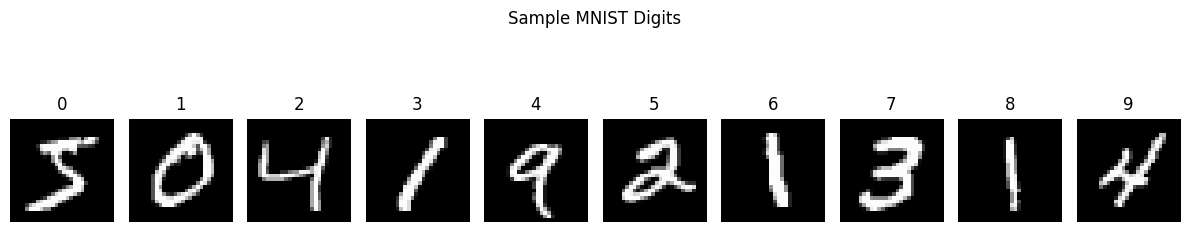

In [ ]:
# ============================================
# 9.2.3 Visualize the MNIST Images
# ============================================

# Display a sample of digits
fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    axes[i].imshow(x_train[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'{i}')
plt.suptitle('Sample MNIST Digits')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 9.2.4 Build the Autoencoder
# ============================================

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))

# Encoder: compress the image
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

# Decoder: reconstruct the image
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 32x32
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display the model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# 9.2.4 Build the Autoencoder (Corrected)
# ============================================

from tensorflow.keras.layers import Cropping2D

# Define the autoencoder architecture
input_img = Input(shape=(28, 28, 1))

# Encoder: compress the image
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)  # 14x14
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)  # 7x7
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4

# Decoder: reconstruct the image
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)  # 8x8
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 16x16
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)  # 32x32

# Crop from 32x32 to 28x28 to match input shape
x = Cropping2D(cropping=((2, 2), (2, 2)))(x)  # Remove 2 pixels from each side

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Create the autoencoder model
autoencoder = Model(input_img, decoded)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Display the model summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 16)       │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,785 (49.94 KB)

 Trainable params: 12,785 (49.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.1951 - val_loss: 0.1376
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1278 - val_loss: 0.1189
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1150 - val_loss: 0.1092
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1082 - val_loss: 0.1047
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1040 - val_loss: 0.1009
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1012 - val_loss: 0.0989
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0991 - val_loss: 0.0968
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0974 - val_loss: 0.0955
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0960 - val_loss: 0.0941
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0950 - val_loss: 0.0943


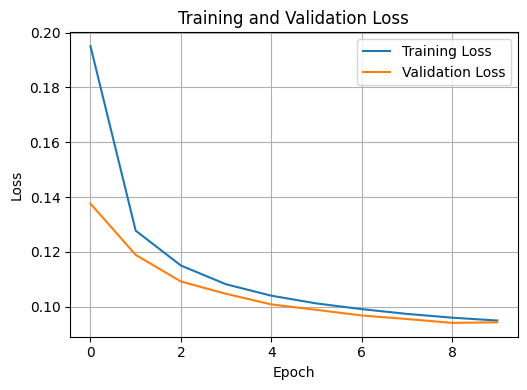

In [ ]:
# ============================================
# 9.2.5 Train the Autoencoder
# ============================================

# Train the autoencoder
history = autoencoder.fit(
    x_train, x_train,  # Input and output are the same
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# Plot the training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step


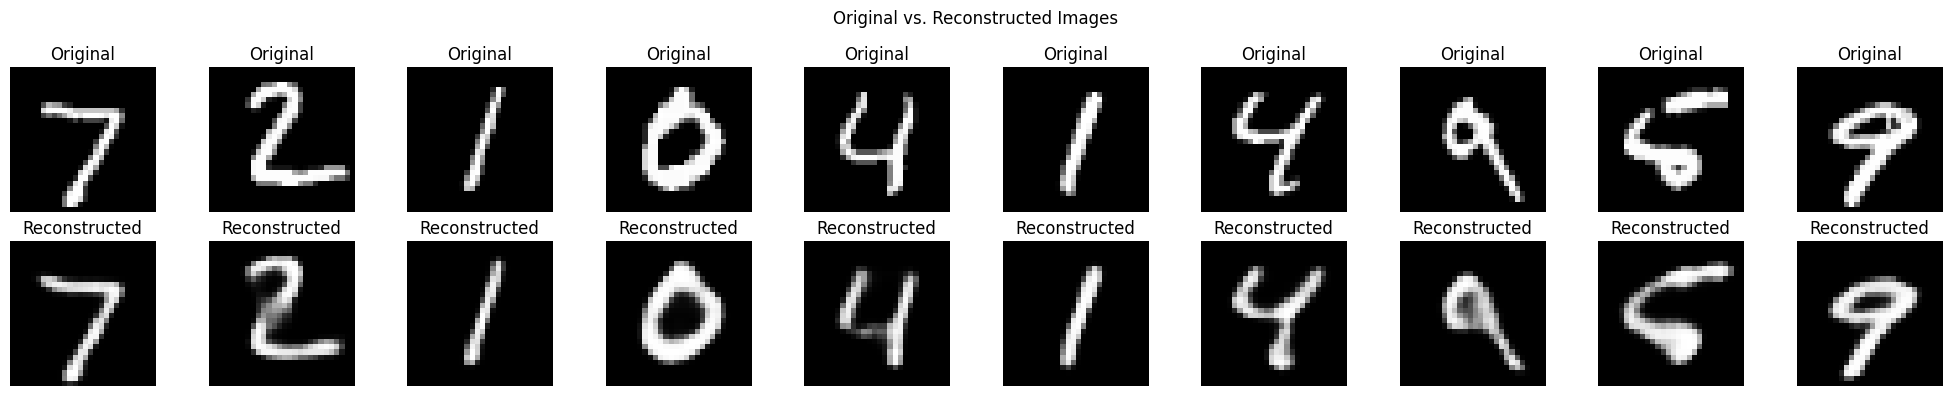

✅ Autoencoder training complete!


In [ ]:
# ============================================
# 9.2.6 Visualize the Reconstructed Images
# ============================================

# Encode and decode some test images
decoded_imgs = autoencoder.predict(x_test[:10])

# Display original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.suptitle('Original vs. Reconstructed Images')
plt.tight_layout()
plt.show()

print("✅ Autoencoder training complete!")

In [ ]:
# ============================================
# 9.3.1 Extract Features from the Encoder
# ============================================

# Extract the encoder part of the autoencoder
encoder = Model(input_img, encoded)

# Encode the test images
encoded_imgs = encoder.predict(x_test)

print(f"Shape of encoded images: {encoded_imgs.shape}")

# Flatten for visualization
encoded_flattened = encoded_imgs.reshape(encoded_imgs.shape[0], -1)
print(f"Flattened shape: {encoded_flattened.shape}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Shape of encoded images: (10000, 4, 4, 8)
Flattened shape: (10000, 128)


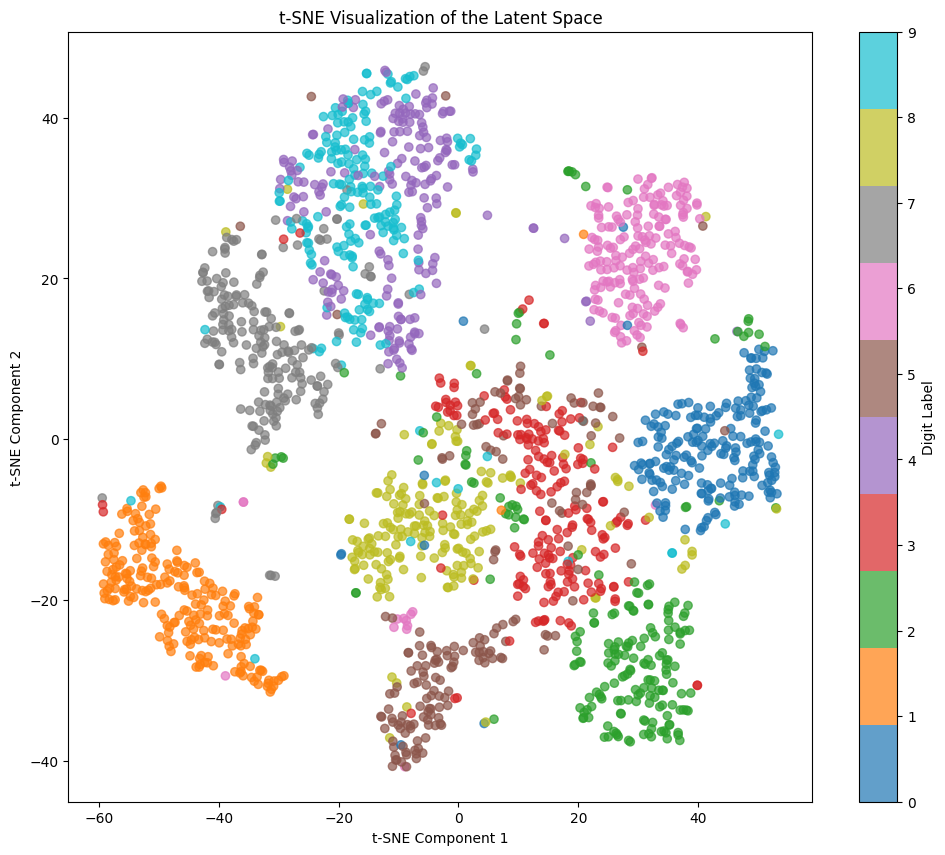

In [ ]:
# ============================================
# 9.3.2 Visualize the Latent Space (Corrected)
# ============================================

from sklearn.manifold import TSNE
import seaborn as sns

# Use only 2000 samples for visualization (to keep it fast)
sample_indices = np.random.choice(len(x_test), 2000, replace=False)
sample_encoded = encoded_flattened[sample_indices]

# Use integer labels directly (y_test is 1D, no argmax needed)
sample_labels = y_test[sample_indices].flatten()

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(sample_encoded)

# Plot the t-SNE results
plt.figure(figsize=(12, 10))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
                     c=sample_labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title('t-SNE Visualization of the Latent Space')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [ ]:
# ============================================
# 9.3.3 Use Autoencoder Features for Classification (Fixed)
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Prepare training data
train_encoded = encoder.predict(x_train).reshape(x_train.shape[0], -1)
test_encoded = encoder.predict(x_test).reshape(x_test.shape[0], -1)

# Scale the encoded features (improves convergence)
scaler = StandardScaler()
train_encoded_scaled = scaler.fit_transform(train_encoded)
test_encoded_scaled = scaler.transform(test_encoded)

# Train a classifier on the scaled encoded features
clf = LogisticRegression(max_iter=2000, random_state=42)
clf.fit(train_encoded_scaled, y_train)

# Evaluate the classifier
y_pred = clf.predict(test_encoded_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification accuracy on encoded features: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification accuracy on encoded features: 0.9747

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [ ]:
# ============================================
# 9.3.4 Compare with Raw Pixel Classification
# ============================================

# Classify using raw pixels
clf_raw = LogisticRegression(max_iter=1000, random_state=42)

# Flatten the raw images
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

clf_raw.fit(x_train_flat, y_train)
y_pred_raw = clf_raw.predict(x_test_flat)
accuracy_raw = accuracy_score(y_test, y_pred_raw)

print(f"Classification accuracy (raw pixels): {accuracy_raw:.4f}")
print(f"Classification accuracy (autoencoder features): {accuracy:.4f}")

Classification accuracy (raw pixels): 0.9259
Classification accuracy (autoencoder features): 0.9747


In [ ]:
# ============================================
# 9.7.4 Feature Extraction Phase
# ============================================

# Load CIFAR-10 as a stand-in for a custom dataset
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Use only a subset for faster training
x_train = x_train[:2000]
y_train = y_train[:2000]
x_test = x_test[:500]
y_test = y_test[:500]

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Resize images to 224x224 for VGG16
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img

def resize_images(images, target_size=(224, 224)):
    resized = []
    for img in images:
        img_pil = array_to_img(img)
        img_resized = img_pil.resize(target_size)
        resized.append(img_to_array(img_resized))
    return np.array(resized)

x_train_resized = resize_images(x_train)
x_test_resized = resize_images(x_test)

print(f"✅ Resized training set: {x_train_resized.shape}")
print(f"✅ Resized test set: {x_test_resized.shape}")

# Load VGG16 without the top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Create the complete model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)

model = Model(inputs, outputs)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with frozen base
history_extraction = model.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy after feature extraction: {test_acc:.4f}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1908s 11us/step
✅ Resized training set: (2000, 224, 224, 3)
✅ Resized test set: (500, 224, 224, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 45s 487ms/step - accuracy: 0.4375 - loss: 1.7454 - val_accuracy: 0.5880 - val_loss: 1.1481
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 204ms/step - accuracy: 0.7255 - loss: 0.7991 - val_accuracy: 0.6460 - val_loss: 0.9904
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 205ms/step - accuracy: 0.8110 - loss: 0.5689 - val_accuracy: 0.6800 - val_loss: 0.9287
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 210ms/step - accuracy: 0.8735 - loss: 0.3957 - val_accuracy: 0.7080 - val_loss: 0.9336
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step - accuracy: 0.9075 - loss: 0.3022 - val_accuracy: 0.7100 - val_loss: 0.8449
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.9355 - loss: 0.2160 - val_accuracy: 0.7260 - val_loss: 0.8501
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━

In [ ]:
# ============================================
# 9.7.5 Fine-Tuning Phase
# ============================================

# Unfreeze the top layers
base_model.trainable = True

# Choose which layers to unfreeze (from block5 onward)
for layer in base_model.layers:
    if 'block5' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

# Recompile with a lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("✅ Fine-tuning ready.")

# Fine-tune the model
history_finetune = model.fit(
    x_train_resized, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_resized, y_test),
    verbose=1
)

# Evaluate
test_loss_ft, test_acc_ft = model.evaluate(x_test_resized, y_test, verbose=0)
print(f"Test accuracy after feature extraction: {test_acc:.4f}")
print(f"Test accuracy after fine-tuning: {test_acc_ft:.4f}")
print(f"Improvement: {(test_acc_ft - test_acc)*100:.2f}%")

✅ Fine-tuning ready.
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 24s 293ms/step - accuracy: 0.9980 - loss: 0.0312 - val_accuracy: 0.7380 - val_loss: 1.0109
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 223ms/step - accuracy: 1.0000 - loss: 0.0092 - val_accuracy: 0.7400 - val_loss: 1.0709
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 229ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.7340 - val_loss: 1.1074
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 233ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7400 - val_loss: 1.1317
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.7300 - val_loss: 1.1757
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 15s 240ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.7380 - val_loss: 1.1799
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - accuracy: 1.0000 - loss: 8.5844e-04 - val_accuracy: 0.7340 - val_loss: 1.2145
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 1.0000 